# **Monte Carlo Simulation for Exotic Option Pricing**

In [18]:
import numpy as np
import matplotlib.pyplot as plt

## Setting up Parameters

In [19]:
T = 10 #total time
N = 100 #step
M = 1000 #number of paths
r = 0.05 #risk-free rate
sigma = 0.2 #volatility
S0 = 100 #initial stock price
barrier = 120 #barrier level
K_values = np.arange(80, 121, 5) #strike prices

## Modeling the stock price : Geometric Brownian Motion

A standard model for stock prices in the Black–Scholes world is the Geometric Brownian Motion (GBM):

$$
dS_t = r S_t\, dt + \sigma S_t\, dW_t
$$

where:

- $S_t$ is the stock price at time $t$
- $r$ is the risk-free interest rate
- $\sigma$ is the volatility
- $W_t$ is a standard Brownian motion

This stochastic differential equation admits the closed-form solution:

$$
S_t = S_0 \exp\!\left( \left( r - \frac{1}{2}\sigma^2 \right)t + \sigma \sqrt{t}\, Z \right)
$$

where $Z \sim \mathcal{N}(0,1)$.


## Monte Carlo Simulation


In [20]:
def simulate_paths(T, N, M):
    dt = T / N
    paths = np.zeros((M, N + 1))
    for m in range(M):
        paths[m, 0] = S0    
        Z = np.random.normal(size=N)  # Standard normal variables
        for i in range(1, N + 1):
            paths[m, i] = paths[m, i - 1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[i-1])
    return paths

def plot_paths(paths, T, N):
    time_grid = np.linspace(0, T, N + 1)
    for path in paths:
        plt.plot(time_grid, path)
    plt.title('Simulated Brownian Motion Paths')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.grid()
    plt.show()

## Visualizing different paths

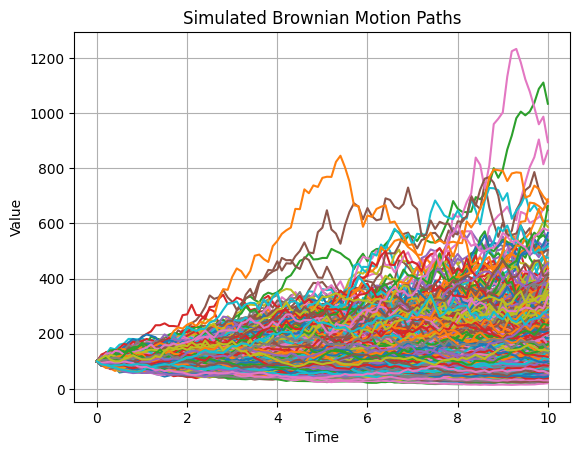

In [21]:
simulated_paths = simulate_paths(T, N, M)
plot_paths(simulated_paths, T, N)

## Estimating the payout and Visualizing price variation based on strike

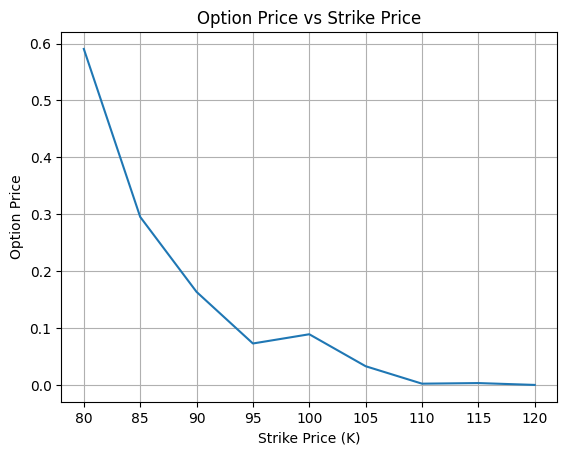

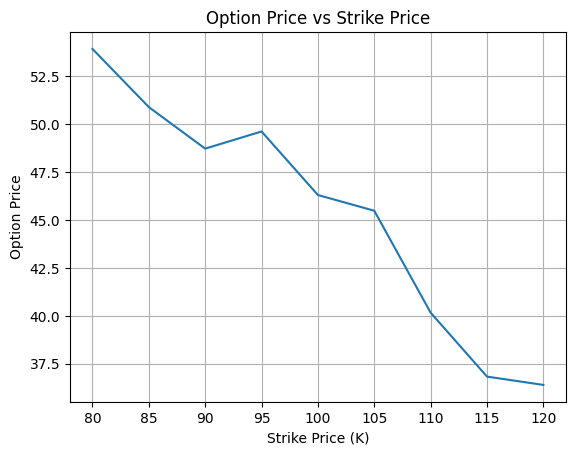

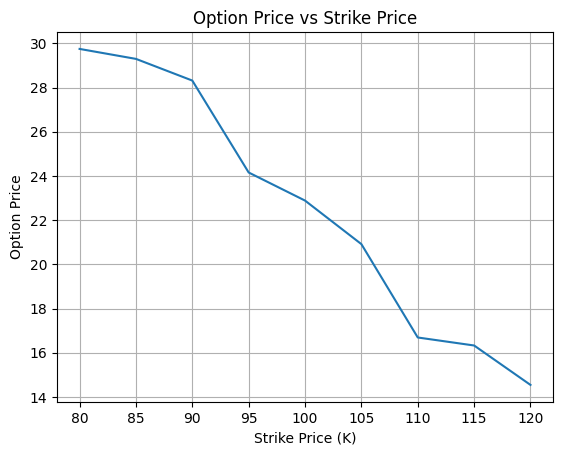

In [22]:
#Calculating the payout for a given path for a Barrier Call option
def barrier_payout(path, K):
    if np.any(path >= barrier):
        return 0
    else:
        return max(path[-1] - K, 0)
    
    
#Calculating the payout for a given path for a European Call option
def european_payout(path,K):
    return max(path[-1]-K,0)

#Calculating the payout for a given path for an Asian Call option
def asian_payout(path,K):
    average_price = np.mean(path)
    return max(average_price - K, 0)


#Estimating the expected payout
def payoff_estimate(K,payout ,num_simulations=M):
    total_payout = 0
    for _ in range(num_simulations):
        path = simulate_paths(T, N, 1)[0]
        total_payout += payout(path, K)
    return total_payout / num_simulations

#Estimating the expected price
def price_estimate(K,payout, r, T, num_simulations=M):
    expected_payoff = payoff_estimate(K,payout, num_simulations)
    return np.exp(-r * T) * expected_payoff


def plot_price_vs_strike(payout, r, T, K_values, num_simulations=M):
    prices = [price_estimate(K, payout, r, T, num_simulations) for K in K_values]
    plt.plot(K_values, prices)
    plt.title('Option Price vs Strike Price')
    plt.xlabel('Strike Price (K)')
    plt.ylabel('Option Price')
    plt.grid()
    plt.show()
    
    

plot_price_vs_strike(barrier_payout, r, T, K_values)
plot_price_vs_strike(european_payout, r, T, K_values)
plot_price_vs_strike(asian_payout, r, T, K_values)